# Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parents[0]

In [2]:
pgcb_dataset = pd.read_csv(ROOT / "data/raw/PGCB_date_power_demand.csv")
weather_dataset = pd.read_csv(ROOT / "data/raw/weather_data.csv", skiprows=3)

In [27]:
import sys
sys.path.insert(0, str(ROOT))

from src.processing import clean_pgcb, clean_weather

pgcb_df = clean_pgcb(pgcb_dataset)
weather_df = clean_weather(weather_dataset)

C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')
C:\Users\ggowt\JupyterWorks\IITG.AI_rec_2\src\processing.py:148: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['time'].min(), df['time'].max(), freq='H')


In [30]:
pgcb_cleaned = pgcb_df[pgcb_df['datetime'].dt.year <= 2023].copy()
weather_cleaned = weather_df[weather_df['time'].dt.year <= 2023].copy()

In [31]:
processed_path = ROOT / "data/processed"
processed_path.mkdir(parents=True, exist_ok=True)

pgcb_cleaned.to_csv(processed_path / "pgcb_cleaned.csv", index=False)
weather_cleaned.to_csv(processed_path / "weather_cleaned.csv", index=False)

In [32]:
economics_dataset = pd.read_csv(ROOT / "data/processed/economic_cleaned_train.csv")
economics_df = economics_dataset.copy()

# Feature_Engineering

## PGCB alone

In [8]:
pgcb_cleaned.columns.tolist()

['datetime',
 'generation_mw',
 'demand_mw',
 'load_shedding',
 'gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura']

### Lag features and rolling means

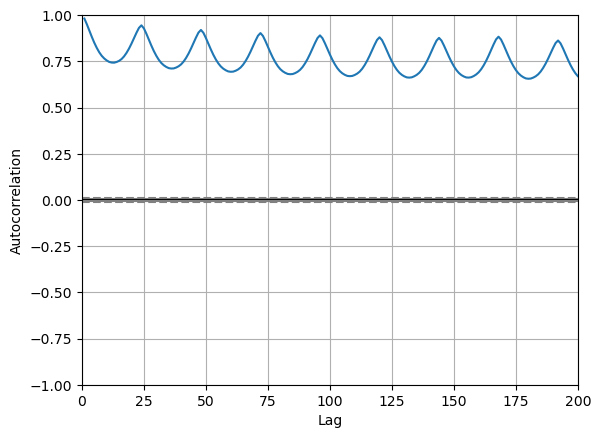

In [9]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(pgcb_cleaned['demand_mw'])
plt.xlim(0, 200)
plt.show()

peaks at 24, 48, 72... = daily cycle (people wake up, use electricity, sleep)
big peak around 168 = same hour last week is a strong predictor

so lags we're keeping:
- lag_1h - adjacent hours are correlated (acf starts at 1.0, drops slow)
- lag_24h  - same hour yesterday
- lag_168h  - same hour last week

In [10]:
pgcb_cleaned = pgcb_cleaned.drop(columns=['generation_mw', 'load_shedding'])

# datetime features
pgcb_cleaned['hour']      = pgcb_cleaned['datetime'].dt.hour
pgcb_cleaned['dayofweek'] = pgcb_cleaned['datetime'].dt.dayofweek
pgcb_cleaned['month']     = pgcb_cleaned['datetime'].dt.month

# lag features
pgcb_cleaned['lag_1h']   = pgcb_cleaned['demand_mw'].shift(1)
pgcb_cleaned['lag_24h']  = pgcb_cleaned['demand_mw'].shift(24)
pgcb_cleaned['lag_168h'] = pgcb_cleaned['demand_mw'].shift(168)

# rolling features
pgcb_cleaned['rolling_mean_24h']  = pgcb_cleaned['demand_mw'].shift(1).rolling(24).mean()
pgcb_cleaned['rolling_mean_168h'] = pgcb_cleaned['demand_mw'].shift(1).rolling(168).mean()

pgcb_cleaned = pgcb_cleaned.dropna(subset=['lag_168h', 'rolling_mean_168h'])

print(pgcb_cleaned.shape)
print(pgcb_cleaned.isnull().sum().sum())

(76128, 18)
0


## Weather

In [11]:
weather_cleaned.columns.tolist()

['time',
 'temperature',
 'relative_humidity',
 'apparent_temperature',
 'precipitation',
 'dew_point',
 'soil_temperature',
 'wind_direction',
 'cloud_cover',
 'sunshine_duration']

### formating Wind Col

In [12]:
weather_cleaned['wind_sin'] = np.sin(np.deg2rad(weather_cleaned['wind_direction']))
weather_cleaned['wind_cos'] = np.cos(np.deg2rad(weather_cleaned['wind_direction']))
weather_cleaned = weather_cleaned.drop(columns=['wind_direction'])

### Merging Datasets

In [13]:
merged = pgcb_cleaned.merge(weather_cleaned, left_on='datetime', right_on='time', how='left')
merged = merged.drop(columns=['time'])
print(merged.shape)
print(merged.isnull().sum().sum())

(76128, 28)
0


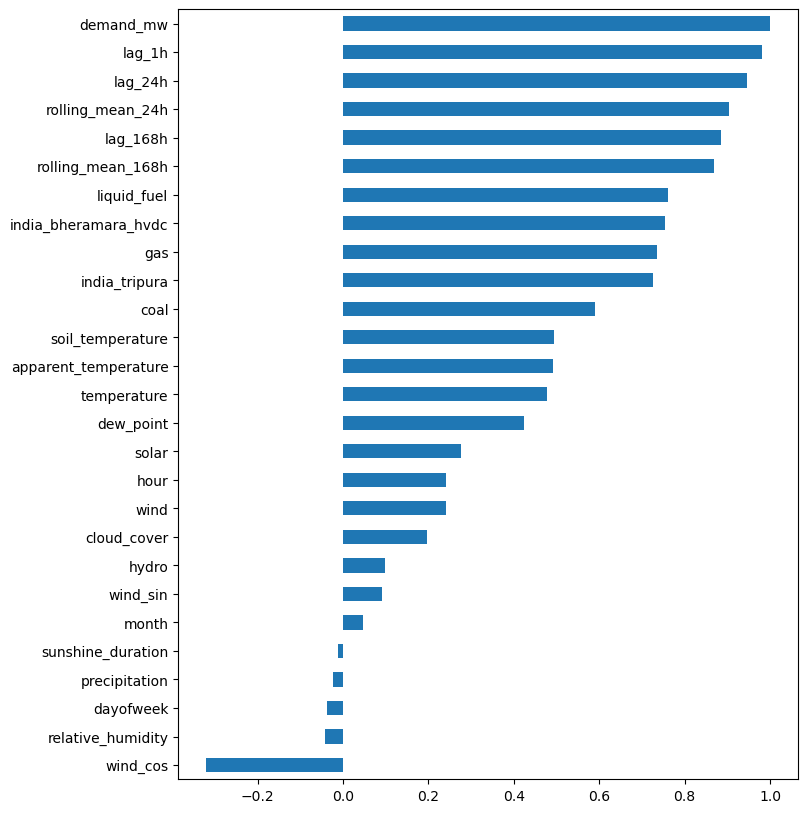

In [14]:
merged.drop(columns=['datetime']).corr()['demand_mw'].sort_values().plot(kind='barh', figsize=(8,10))
plt.show()

#### Sunshine vs Solar

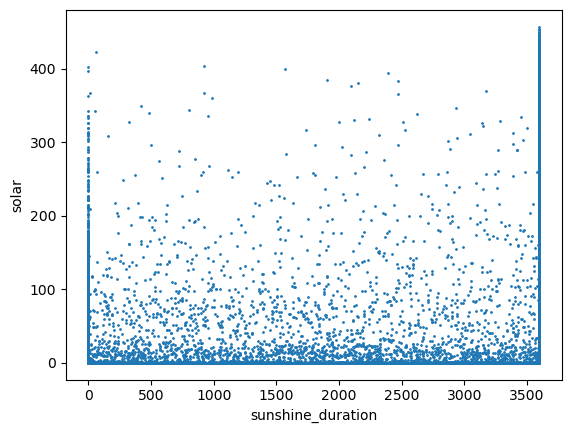

In [15]:
plt.scatter(merged['sunshine_duration'], merged['solar'], s=1)
plt.xlabel('sunshine_duration')
plt.ylabel('solar')
plt.show()

#### Precipitation vs Demand

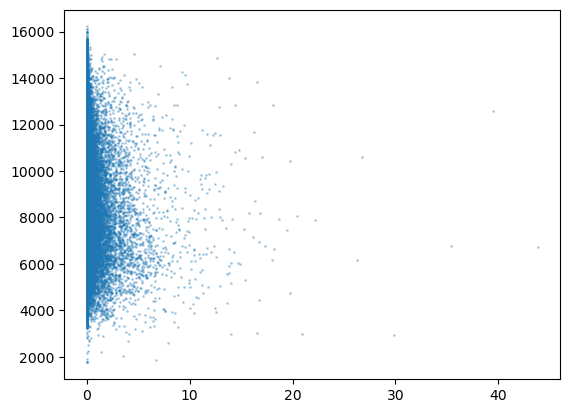

In [16]:
plt.scatter(merged['precipitation'], merged['demand_mw'], s=1, alpha=0.3)
plt.show()

precipitation — 99% of data piled at 0-5mm, demand shows no pattern with it.
Dropping the precipitation is ok.

#### Demand vs day of the week and month

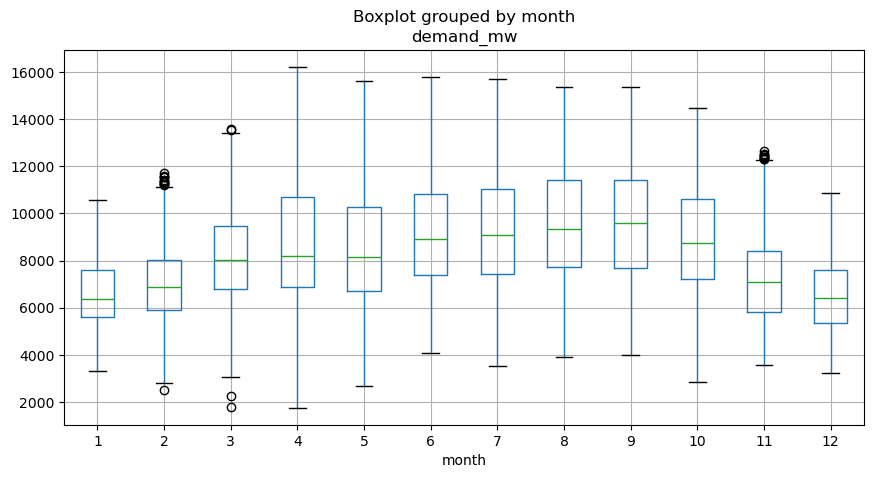

In [17]:
merged.boxplot(column='demand_mw', by='month', figsize=(10,5))
plt.show()

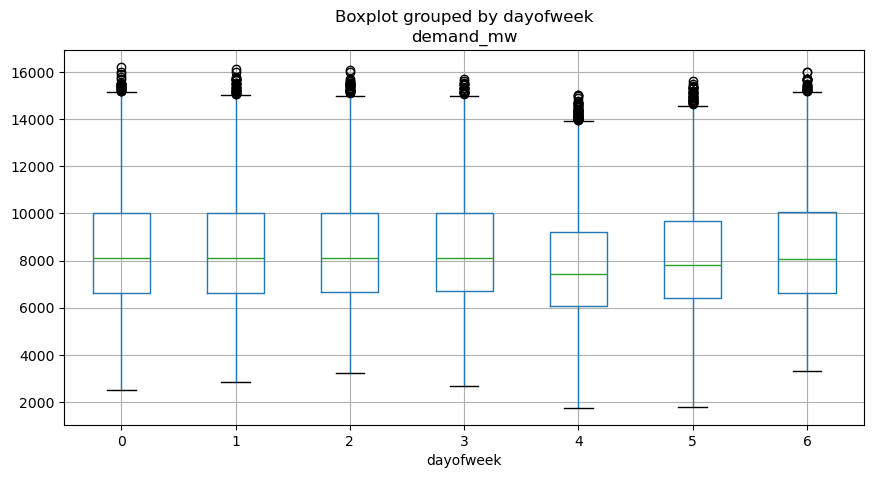

In [18]:
merged.boxplot(column='demand_mw', by='dayofweek', figsize=(10,5))
plt.show()

dayofweek — day 4 (Friday) median visibly lower than rest. That's the Bangladesh holiday effect showing up cleanly.
We can keep this.

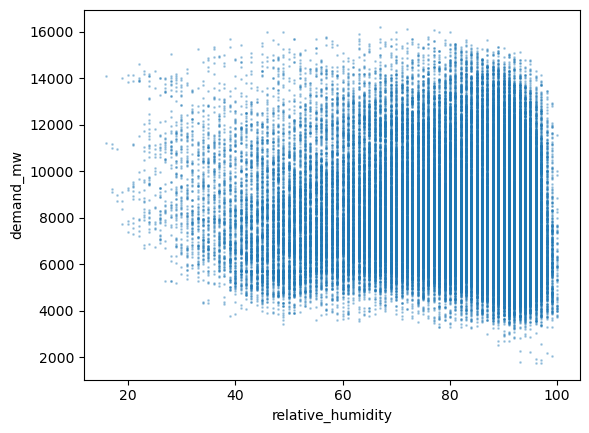

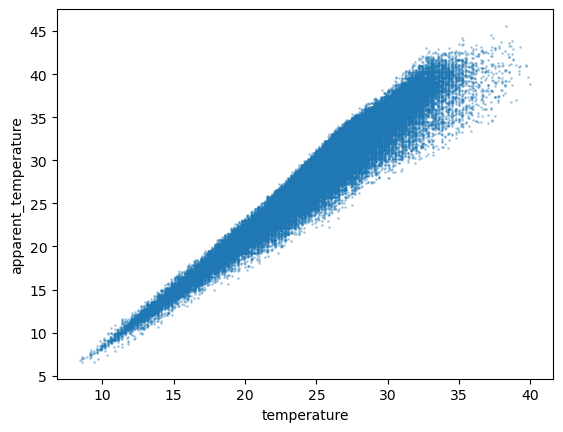

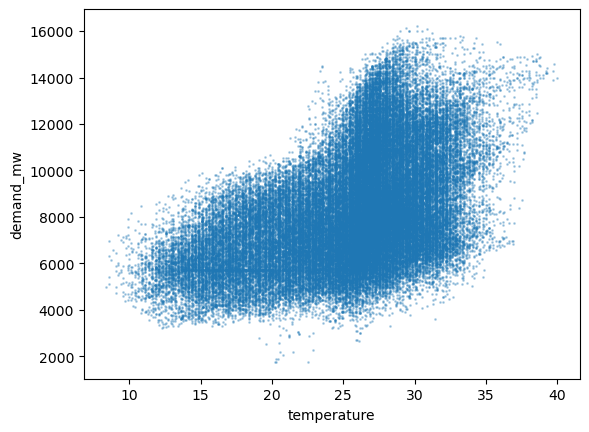

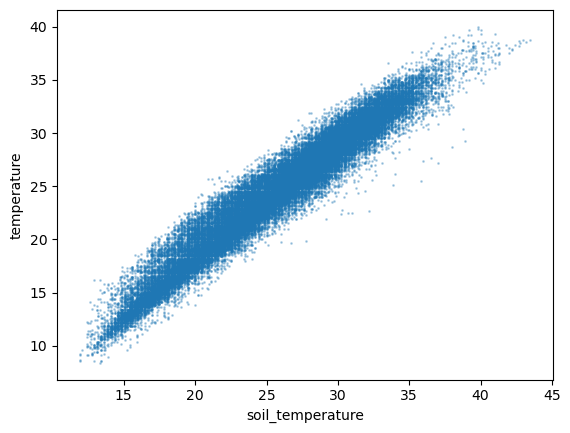

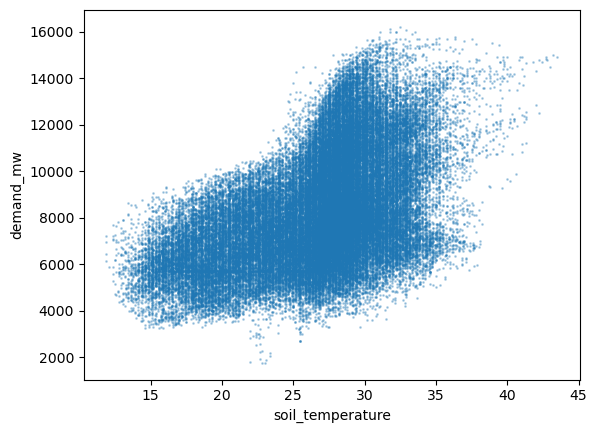

In [19]:
# humidity vs demand
plt.scatter(merged['relative_humidity'], merged['demand_mw'], s=1, alpha=0.3)
plt.xlabel('relative_humidity')
plt.ylabel('demand_mw')
plt.show()

# temperature vs apparent_temperature
plt.scatter(merged['temperature'], merged['apparent_temperature'], s=1, alpha=0.3)
plt.xlabel('temperature')
plt.ylabel('apparent_temperature')
plt.show()

# temperature vs demand_mw
plt.scatter(merged['temperature'], merged['demand_mw'], s=1, alpha=0.3)
plt.xlabel('temperature')
plt.ylabel('demand_mw')
plt.show()


# soil_temperature vs temperature
plt.scatter(merged['soil_temperature'], merged['temperature'], s=1, alpha=0.3)
plt.xlabel('soil_temperature')
plt.ylabel('temperature')
plt.show()

# soil_temperature vs demand
plt.scatter(merged['soil_temperature'], merged['demand_mw'], s=1, alpha=0.3)
plt.xlabel('soil_temperature')
plt.ylabel('demand_mw')
plt.show()

Temperature, App_Temp and Soil_Temp are almost close and linear in relatinship. So, we can remove extra features and can reduce dimensionality

In [20]:
merged = merged.drop(columns=['temperature', 'soil_temperature', 'relative_humidity'])

In [21]:
print(merged.columns.tolist())
print(merged.shape)

['datetime', 'demand_mw', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'hour', 'dayofweek', 'month', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_168h', 'apparent_temperature', 'precipitation', 'dew_point', 'cloud_cover', 'sunshine_duration', 'wind_sin', 'wind_cos']
(76128, 25)


## Economics

In [22]:
economics_df.shape

(7, 13)

In [23]:
economics_df.head()

,Country Name,Indicator Name,Indicator Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,X,Population growth (annual %),SP.POP.GROW,8.938194e-01,8.924324e-01,8.509173e-01,8.209552e-01,8.464113e-01,8.363108e-01,8.149780e-01,1.024234e+00,1.221715e+00,1.214621e+00
1,X,"Manufacturing, value added (% of GDP)",NV.IND.MANF.ZS,1.678867e+01,2.034795e+01,2.007506e+01,2.080230e+01,2.120794e+01,2.059833e+01,2.123567e+01,2.176482e+01,2.234202e+01,2.189296e+01
2,X,Access to electricity (% of population),EG.ELC.ACCS.ZS,7.400000e+01,7.590000e+01,8.800000e+01,8.690000e+01,9.220000e+01,9.620000e+01,9.900000e+01,9.940000e+01,9.950000e+01,8.678119e+07
3,X,"Population, total",SP.POP.TOTL,1.593832e+08,1.608119e+08,1.621861e+08,1.635231e+08,1.649131e+08,1.662980e+08,1.676589e+08,1.693849e+08,1.714670e+08,1.735624e+08
4,X,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,6.552640e+00,7.113478e+00,6.590250e+00,7.319413e+00,7.881915e+00,3.448018e+00,6.938679e+00,7.099829e+00,5.775112e+00,4.223259e+00


In [25]:
year_cols = [str(y) for y in range(2015, 2024)]
economic_cleaned = economics_df.set_index('Indicator Code')[year_cols].T
economic_cleaned.index.name = 'year'
economic_cleaned.index = economic_cleaned.index.astype(int)

# derived features
economic_cleaned['gdp_per_capita'] = economic_cleaned['NY.GDP.MKTP.CD'] / economic_cleaned['SP.POP.TOTL']
economic_cleaned['econ_growth']    = economic_cleaned['NY.GDP.MKTP.KD.ZG'] * economic_cleaned['SP.POP.GROW']

# join
merged['year'] = merged['datetime'].dt.year
merged = merged.merge(economic_cleaned, on='year', how='left')
merged = merged.drop(columns=['year'])

print(merged.shape)
print(merged.isnull().sum().sum())

(76128, 34)
0


In [26]:
merged.columns

Index(['datetime', 'demand_mw', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar',
       'wind', 'india_bheramara_hvdc', 'india_tripura', 'hour', 'dayofweek',
       'month', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h',
       'rolling_mean_168h', 'apparent_temperature', 'precipitation',
       'dew_point', 'cloud_cover', 'sunshine_duration', 'wind_sin', 'wind_cos',
       'SP.POP.GROW', 'NV.IND.MANF.ZS', 'EG.ELC.ACCS.ZS', 'SP.POP.TOTL',
       'NY.GDP.MKTP.KD.ZG', 'NY.GDP.MKTP.CD', 'NV.IND.MANF.KD.ZG',
       'gdp_per_capita', 'econ_growth'],
      dtype='object')